#  Customer Churn Prediction and Analysis

## Introduction
Customer churn refers to the phenomenon where customers stop doing business with a company. In highly competitive industries, retaining customers is crucial for business success.

This project aims to analyze customer data and build a machine learning model to predict customer churn. By identifying patterns and key factors influencing churn, businesses can take proactive measures to improve customer retention.

---

##  Objectives
- Analyze customer data to understand churn behavior
- Perform data preprocessing and cleaning
- Conduct exploratory data analysis (EDA)
- Build machine learning models to predict churn
- Identify key factors affecting customer retention
- Provide actionable business insights

---

##  Tools & Technologies Used
- Python (Pandas, NumPy, Scikit-learn)
- Data Visualization (Matplotlib, Seaborn)
- Google Colab

## Data Loading

In this step, we load the dataset into the environment using Pandas. The dataset contains customer information such as demographics, services subscribed, account details, and whether the customer has churned.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##  Data Understanding

Understanding the structure of the dataset is important before performing analysis. This includes checking the number of rows, columns, data types, and missing values.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Statistical Summary

This provides a statistical overview of numerical features in the dataset, including mean, standard deviation, minimum, and maximum values.

In [3]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


##  Target Variable Analysis

The target variable in this project is 'Churn', which indicates whether a customer has left the company. Analyzing its distribution helps us understand the balance of the dataset.

In [4]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


##  Data Cleaning and Preprocessing

In this phase, we handle missing values, fix data types, and prepare the dataset for analysis and modeling.

In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


###  Fixing Data Types

The 'TotalCharges' column is incorrectly stored as a string. We convert it to a numeric type for proper analysis.

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

###  Handling Missing Values

Missing values in the dataset can affect model performance. We remove rows with missing values to ensure data quality.

In [7]:
df = df.dropna()

In [8]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### Encoding Target Variable

The 'Churn' column contains categorical values (Yes/No). We convert them into numerical format (1/0) for machine learning.

In [9]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

###  Encoding Categorical Variables

Machine learning models require numerical input. We convert categorical features into numerical form using encoding techniques.

In [10]:
df = pd.get_dummies(df, drop_first=True)

##  Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand patterns, relationships, and trends in the dataset using statistical summaries and visualizations.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

###  Churn Distribution

This visualization shows the proportion of customers who stayed versus those who churned.

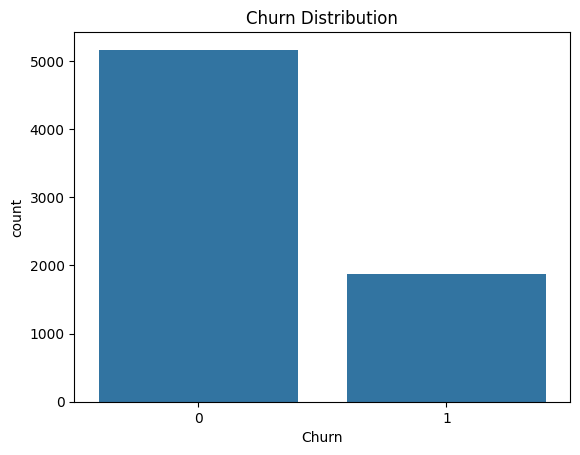

In [12]:
sns.countplot(x='Churn', data=df)
plt.title("Churn Distribution")
plt.show()

Insight:
Most customers did not churn, but a significant portion did. This indicates a class imbalance problem which needs to be considered during modeling.

###  Tenure vs Churn

This plot shows how long customers stay with the company and how it relates to churn.

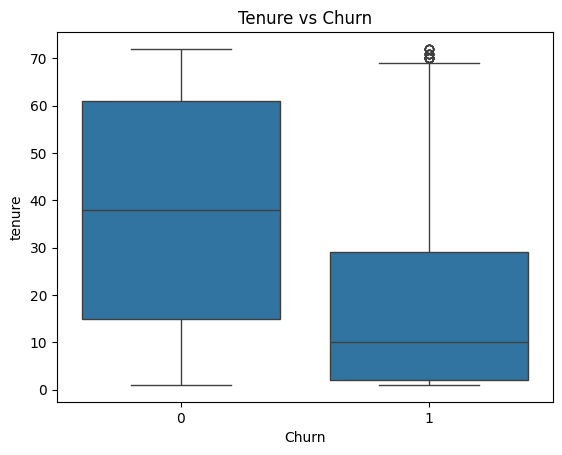

In [13]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()

Insight:
Customers with lower tenure are more likely to churn, while long-term customers tend to stay.

###  Monthly Charges vs Churn

This visualization shows whether higher monthly charges influence churn behavior.

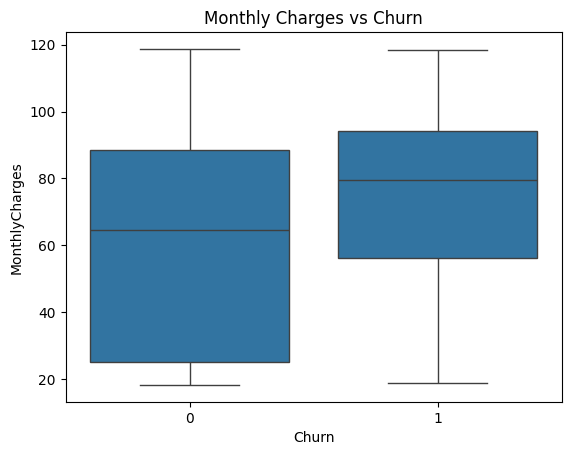

In [14]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

Insight:
Customers with higher monthly charges tend to churn more frequently.

###  Correlation Heatmap

This heatmap shows relationships between numerical features in the dataset.

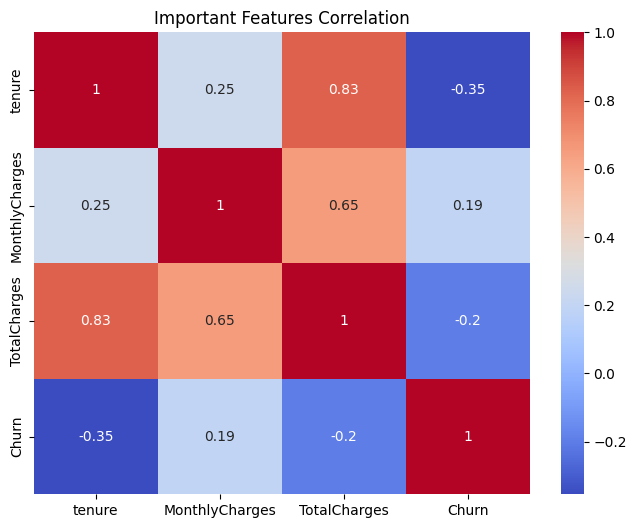

In [15]:
important_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

plt.figure(figsize=(8,6))
sns.heatmap(df[important_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Important Features Correlation")
plt.show()

Insight:
The correlation heatmap shows that tenure has a negative correlation with churn, indicating that customers who stay longer are less likely to leave. Monthly charges show a positive relationship with churn, suggesting higher-paying customers are more likely to churn.

##  Machine Learning Model

In this section, we build machine learning models to predict customer churn based on the processed dataset.

###  Splitting Features and Target Variable

We separate the dataset into input features (X) and target variable (y).

In [16]:
X = df.drop('Churn', axis=1)
y = df['Churn']

###  Train-Test Split

We split the dataset into training and testing sets to evaluate model performance.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

###  Logistic Regression Model

Logistic Regression is a classification algorithm used to predict binary outcomes such as churn (Yes/No).

In [18]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

###  Model Predictions

We use the trained model to make predictions on the test data.

In [19]:
y_pred = model.predict(X_test)

###  Model Evaluation

We evaluate the model using accuracy, confusion matrix, and classification report.

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7825159914712153

Confusion Matrix:
 [[903 130]
 [176 198]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.87      0.86      1033
           1       0.60      0.53      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



###  Random Forest Model

Random Forest is an ensemble learning method that builds multiple decision trees and combines their outputs to improve prediction accuracy.

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [22]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7896233120113717

Confusion Matrix:
 [[947  86]
 [210 164]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.66      0.44      0.53       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.70      1407
weighted avg       0.78      0.79      0.77      1407



Insight:
The Random Forest model performed better than Logistic Regression, indicating that ensemble methods can capture complex patterns in the data more effectively.

###  Feature Importance

Feature importance helps identify which variables have the most influence on predicting customer churn.

In [23]:
import pandas as pd

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).head(10)

,0
TotalCharges,0.102437
tenure,0.095978
MonthlyCharges,0.083280
InternetService_Fiber optic,0.026298
TechSupport_Yes,0.021811
Contract_Two year,0.021601
PaymentMethod_Electronic check,0.021445
OnlineSecurity_Yes,0.021355
Contract_One year,0.017938
PaperlessBilling_Yes,0.017083


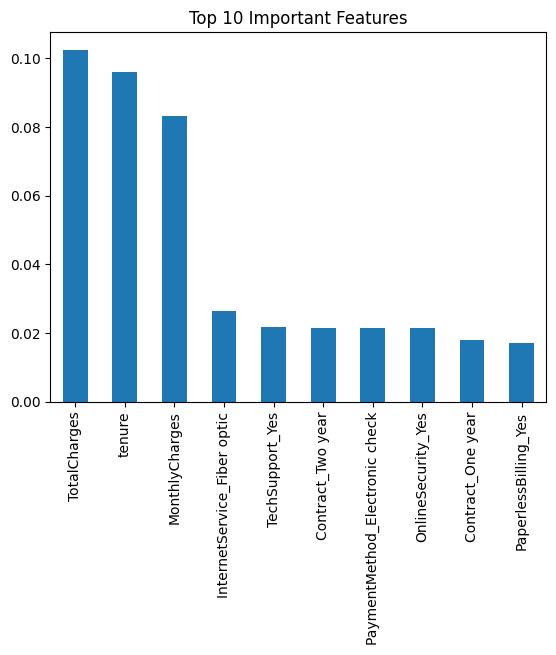

In [24]:
feature_importance.sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Important Features")
plt.show()

Insight:
The most important feature influencing customer churn is TotalCharges, followed by tenure and MonthlyCharges. This indicates that overall spending and customer lifetime value play a crucial role in churn behavior. Customers with lower tenure and higher monthly costs are more likely to leave, highlighting the importance of long-term engagement and pricing strategies in customer retention.